# LangGraph Agent
## Without tools

## Library Imports

In [3]:
from langchain_core.messages import AIMessage, HumanMessage
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import START, StateGraph, MessagesState
import logging
import os
from IPython.display import Image, Markdown, display
from langchain_core.runnables.graph import MermaidDrawMethod
from dotenv import load_dotenv

## Configure logging

In [ ]:
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)
    
logging.basicConfig(filename='langgraph_notebook.log',
                    level=logging.INFO,
                    )

## Configure Agent and Model

In [8]:
# load environment variables from .env file
load_dotenv()

# Configure NVIDIA API from environment variables
NVIDIA_API_KEY = os.environ.get("NVIDIA_API_KEY")
if not NVIDIA_API_KEY:
    raise ValueError(
        "NVIDIA_API_KEY environment variable not set. "
        "Please set it: export NVIDIA_API_KEY='your_token_here'\n"
        "Get a free key at: https://platform.nvidia.com/ai/endpoints/"
    )

model = ChatNVIDIA(
    model="qwen/qwen3-coder-480b-a35b-instruct",  # or any other supported model
    api_key=NVIDIA_API_KEY,
    temperature=0.7,
    top_p=0.8,
    max_completion_tokens=4096,
)

def call_model(state: MessagesState):
    '''send messages to the model using the state object'''
    messages = state['messages']
    try:
        response = model.invoke(messages)
    except Exception as exc:
        response = AIMessage(
            content=f"NVIDIA API unavailable. Details: {exc}\n\nCheck your NVIDIA_API_KEY and quota."
        )
    return {"messages": [response]}

workflow = StateGraph(MessagesState) # define the tasks available to the agent

workflow.add_node("agent", call_model) # use the call_model function to send messages to the model and get responses

workflow.add_edge(START, "agent") # start of the graph

checkpointer = MemorySaver()

app = workflow.compile(checkpointer=checkpointer) # compile the graph into a runnable application


/workspaces/ai-project/.venv/lib/python3.12/site-packages/langchain_nvidia_ai_endpoints/_common.py:243: UserWarning: Found qwen/qwen3-coder-480b-a35b-instruct in available_models, but type is unknown and inference may fail.
  warnings.warn(


## Visualize the Graph

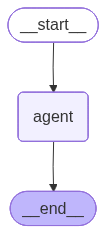

In [9]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

## Chat with the Agent

In [10]:
final_state = app.invoke(
    {"messages": [HumanMessage(content="What teams did Joe Montana play for?")]},
    config={"configurable": {"thread_id": 99}},
)
display(Markdown(final_state['messages'][-1].content))

Joe Montana played for two NFL teams during his career:

1. **San Francisco 49ers** (1979-1992) - This was his primary team where he won four Super Bowl championships and became one of the greatest quarterbacks in NFL history.

2. **Kansas City Chiefs** (1993-1994) - He finished his career with the Chiefs, though he was injured for much of his time there and didn't play as significant a role as he had in San Francisco.

Montana is most famously associated with the 49ers, where he established his legendary status in football.

In [11]:
final_state = app.invoke(
    {"messages": [HumanMessage(content="What are the leagues in the SportsWorldCentral fantasy football platform?")]},
    config={"configurable": {"thread_id": 99}}
)
display(Markdown(final_state["messages"][-1].content))

I don't have specific information about the SportsWorldCentral fantasy football platform or its league structure in my knowledge base. To get accurate details about their leagues, I'd recommend:

1. Checking the SportsWorldCentral website directly
2. Looking at their help documentation or FAQ section
3. Contacting their customer support
4. Looking for a "league types" or "game formats" section in their platform

Generally, most fantasy football platforms offer standard leagues (like 10-team or 12-team formats), but the specific league types and formats can vary significantly between platforms. The best source for accurate, up-to-date information about SportsWorldCentral's specific offerings would be their official documentation.